In [2]:
import pandas as pd

df_sales = pd.read_csv('Sales.csv')
print(df_sales.head())

         Date  Day     Month  Year  Customer_Age       Age_Group  \
0  2013-11-26   26  November  2013            19     Youth (<25)   
1  2015-11-26   26  November  2015            19     Youth (<25)   
2  2014-03-23   23     March  2014            49  Adults (35-64)   
3  2016-03-23   23     March  2016            49  Adults (35-64)   
4  2014-05-15   15       May  2014            47  Adults (35-64)   

  Customer_Gender    Country             State Product_Category Sub_Category  \
0               M     Canada  British Columbia      Accessories   Bike Racks   
1               M     Canada  British Columbia      Accessories   Bike Racks   
2               M  Australia   New South Wales      Accessories   Bike Racks   
3               M  Australia   New South Wales      Accessories   Bike Racks   
4               F  Australia   New South Wales      Accessories   Bike Racks   

               Product  Order_Quantity  Unit_Cost  Unit_Price  Profit  Cost  \
0  Hitch Rack - 4-Bike         

In [3]:
features = [
    'Customer_Age',
    'Order_Quantity',
    'Unit_Cost',
    'Unit_Price',
    'Profit',
    'Cost',
    'Revenue'
]

X = df_sales[features]

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.66519445 0.14402961]


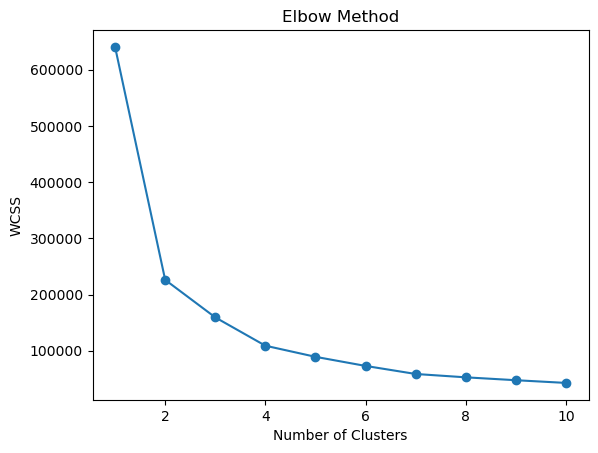

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [7]:
from sklearn.metrics import silhouette_score

sample = pd.DataFrame(X_pca).sample(
    n=5000,
    random_state=42
)

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(sample)

    score = silhouette_score(
        sample,
        labels
    )

    print(f"K={k}: {score:.3f}")

K=2: 0.704
K=3: 0.459
K=4: 0.469
K=5: 0.469
K=6: 0.407
K=7: 0.434
K=8: 0.393
K=9: 0.388
K=10: 0.403


In [8]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df_sales['Cluster'] = kmeans.fit_predict(X_pca)

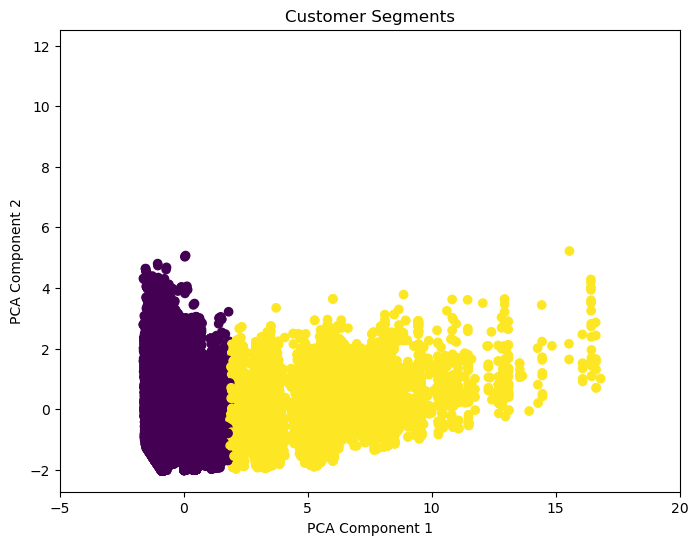

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_sales['Cluster']
)

plt.xlim(-5,20)

plt.title('Customer Segments')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.show()